In [51]:
import cv2
import os
import matplotlib.pyplot as plt

# SPDFI

In [52]:
# setup
TARGET_IMG_PATH = "./CV_Session6/Dataset/Object.jpg"
CANDIDATE_PATH = "./CV_Session6/Dataset/Data/"

In [53]:
# preprocess
targetBgr = cv2.imread(TARGET_IMG_PATH)
targetRgb = cv2.cvtColor(targetBgr, cv2.COLOR_BGR2RGB)
targetGrayBlur = cv2.medianBlur(cv2.cvtColor(targetRgb, cv2.COLOR_RGB2GRAY), 3)

candidates = []
for fileName in os.listdir(CANDIDATE_PATH):
    candidateBgr = cv2.imread(os.path.join(CANDIDATE_PATH, fileName))

    # if not os.path.isfile(candidateBgr):
    #     continue

    candidates.append((fileName, candidateBgr))

In [54]:
# detect
akaze = cv2.AKAZE_create()
targetKp, targetDesc = akaze.detectAndCompute(targetGrayBlur, None)

bestMatchCount = 0

In [55]:
# feature matching
bfMatcher = cv2.BFMatcher(cv2.NORM_HAMMING)

for fileName, candidateBgr in candidates:
    candidateGrayBlur = cv2.medianBlur(cv2.cvtColor(candidateBgr, cv2.COLOR_BGR2GRAY), 3)
    candidateKp, candidateDesc = akaze.detectAndCompute(candidateGrayBlur, None)

    knnMatch = bfMatcher.knnMatch(targetDesc, candidateDesc, k=2)

    bestMatch = []
    for matchPair in knnMatch:
        fm, sm = matchPair
        if fm.distance < 0.75 * sm.distance:
            bestMatch.append(fm)

    if bestMatchCount < len(bestMatch):
        bestMatchCount = len(bestMatch)
        bestMatchData = {
            "fileName" : fileName,
            "imageBgr" : candidateBgr,
            "keypoint" : candidateKp,
            "bestMatch" : sorted(bestMatch, key=lambda m:m.distance)[:120]
        }

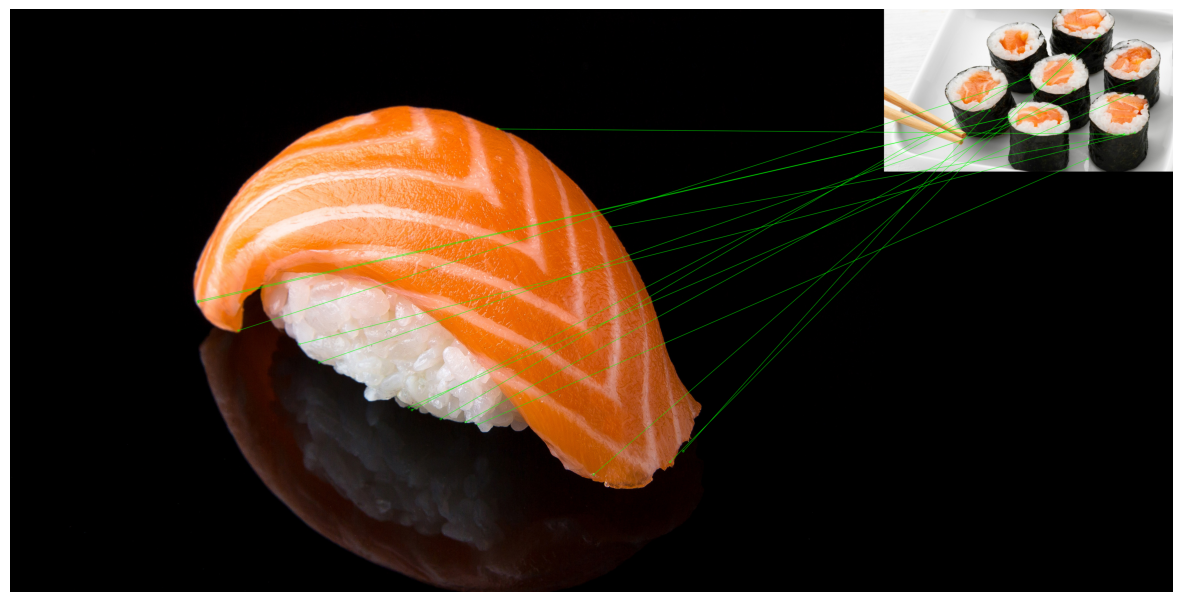

In [56]:
# inference
bestMatchRgb = cv2.cvtColor(bestMatchData["imageBgr"], cv2.COLOR_BGR2RGB)

result = cv2.drawMatches(
    targetRgb,
    targetKp,
    bestMatchRgb,
    bestMatchData["keypoint"],
    bestMatchData["bestMatch"],
    None,
    matchColor=(0,255,0),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(15,30))
plt.imshow(result)
plt.axis(False)
plt.show()